In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Define time periods
TIME_PERIODS = [
    {'start': 1904, 'end': 1930, 'name': 'Early Era'},
    {'start': 1931, 'end': 1980, 'name': 'Mid-Century Era'},
    {'start': 1981, 'end': 2025, 'name': 'Modern Era'}
]

# Toggle to exclude COVID years
EXCLUDE_COVID_YEARS = True  # Set to False to include all years
YEARS_TO_EXCLUDE = [2020, 2021] 

# ASYMMETRIC Z-score thresholds for outlier detection
POSITIVE_Z_THRESHOLD = 1.5
NEGATIVE_Z_THRESHOLD = 1.0 

# Minimum number of parks required for a year to be included
MIN_PARKS_REQUIRED = 1

print(f"{'='*80}")
print(f"MULTI-PERIOD PARK VISITATION ANALYSIS")
if EXCLUDE_COVID_YEARS:
    print(f"EXCLUDING YEARS: {YEARS_TO_EXCLUDE}")
print(f"Time Periods: {len(TIME_PERIODS)}")
for period in TIME_PERIODS:
    print(f"  - {period['name']}: {period['start']}-{period['end']}")
print(f"Outlier Thresholds: +{POSITIVE_Z_THRESHOLD} SD (increases), -{NEGATIVE_Z_THRESHOLD} SD (decreases)")
print(f"{'='*80}\n")

MULTI-PERIOD PARK VISITATION ANALYSIS
EXCLUDING YEARS: [2020, 2021]
Time Periods: 3
  - Early Era: 1904-1930
  - Mid-Century Era: 1931-1980
  - Modern Era: 1981-2025
Outlier Thresholds: +1.5 SD (increases), -1.0 SD (decreases)



In [10]:
# ============================================================================
# Load and Prepare Data
# ============================================================================

df_raw = pd.read_csv('/Users/namithageorge/msai339/project/National-Parks-DS/Datasets/historic_park_data.csv')
df_raw['Total'] = (
    df_raw['Total']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

print("Raw data shape:", df_raw.shape)

# Aggregate to annual totals
df_annual = df_raw.groupby(['ParkName', 'Year'])['Total'].sum().reset_index()

# Pivot to parks × years
df_pivot = df_annual.pivot(index='ParkName', columns='Year', values='Total')
df_all = df_pivot.sort_index(axis=1)

print(f"Total data range: {df_all.columns.min()} to {df_all.columns.max()}")
print(f"Total parks: {len(df_all)}\n")

Raw data shape: (5282, 7)
Total data range: 1904 to 2024
Total parks: 63




ANALYZING: Early Era (1904-1930)
Years in period: 27
Year range: 1904 to 1930
Parks with data (first year): 0
Parks with data (last year): 24

Period Statistics:
  Mean change: 5,263 visitors
  Std deviation: 5,704 visitors

Outlier Years in Early Era: [1906, 1910, 1914, 1918, 1919, 1925]


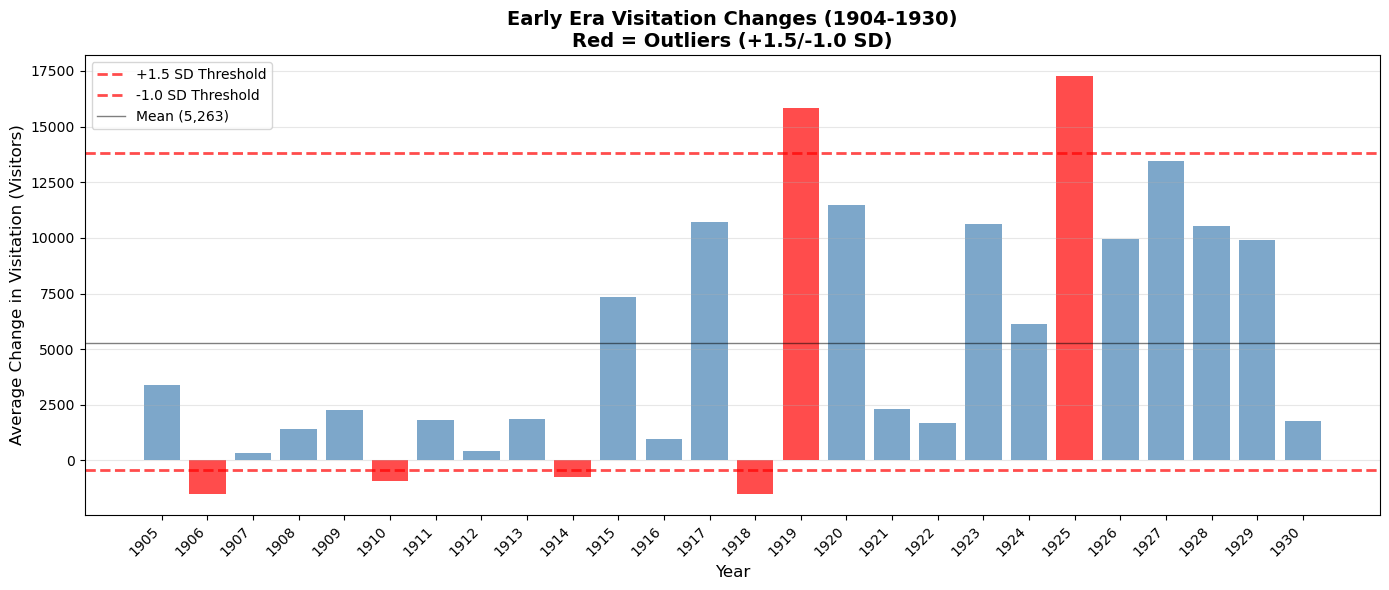


--- Early Era Summary ---
Years analyzed: 26
Outlier years: 6

Positive outliers (increases > +1.5 SD):
  1925: Z=2.10, Change=17,262
  1919: Z=1.86, Change=15,848

Negative outliers (decreases < -1.0 SD):
  1906: Z=-1.19, Change=-1,500
  1918: Z=-1.19, Change=-1,499
  1910: Z=-1.09, Change=-935

Chart saved as: period_1904_1930_early_era_excl.png

ANALYZING: Mid-Century Era (1931-1980)
Years in period: 50
Year range: 1931 to 1980
Parks with data (first year): 0
Parks with data (last year): 55

Period Statistics:
  Mean change: 31,873 visitors
  Std deviation: 59,646 visitors

Outlier Years in Mid-Century Era: [1942, 1943, 1971, 1974, 1979]


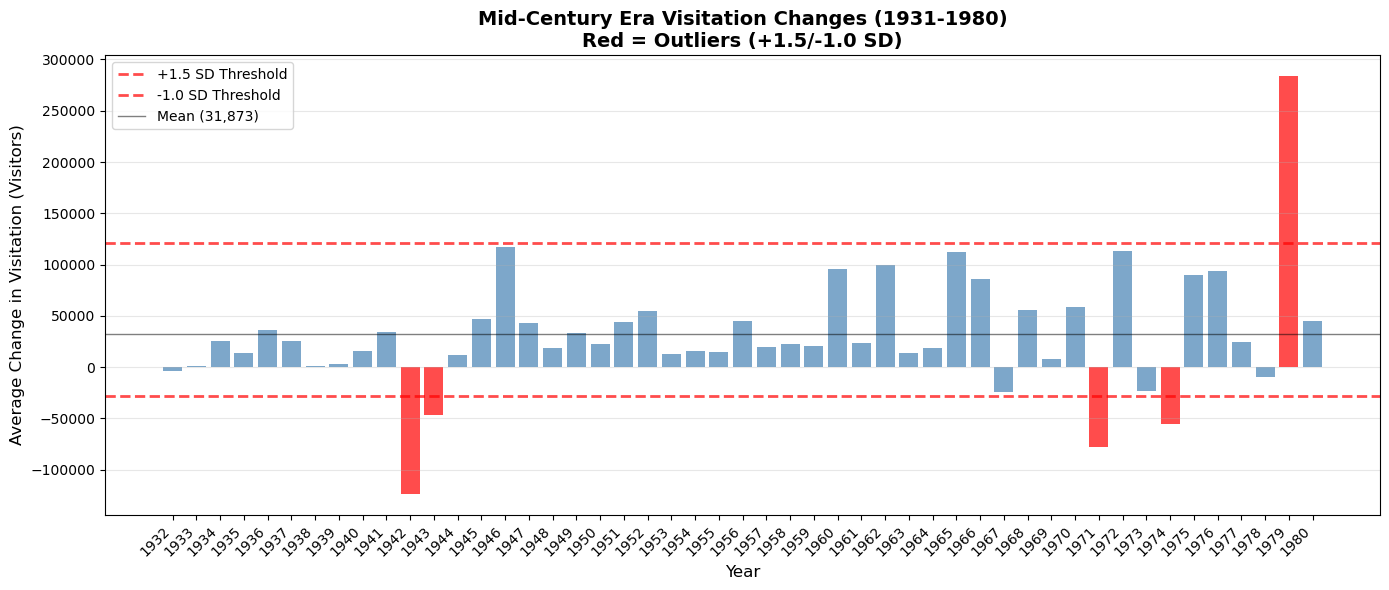


--- Mid-Century Era Summary ---
Years analyzed: 49
Outlier years: 5

Positive outliers (increases > +1.5 SD):
  1979: Z=4.22, Change=283,684

Negative outliers (decreases < -1.0 SD):
  1942: Z=-2.60, Change=-123,501
  1971: Z=-1.83, Change=-77,396
  1974: Z=-1.47, Change=-55,557

Chart saved as: period_1931_1980_mid-century_era_excl.png

ANALYZING: Modern Era (1981-2025)
Years in period: 42
Year range: 1981 to 2024
Parks with data (first year): 0
Parks with data (last year): 63

Period Statistics:
  Mean change: 18,258 visitors
  Std deviation: 47,111 visitors

Outlier Years in Modern Era: [1987, 1990, 1996, 2000, 2001, 2006, 2008, 2011, 2013, 2014, 2015, 2016, 2018, 2022]


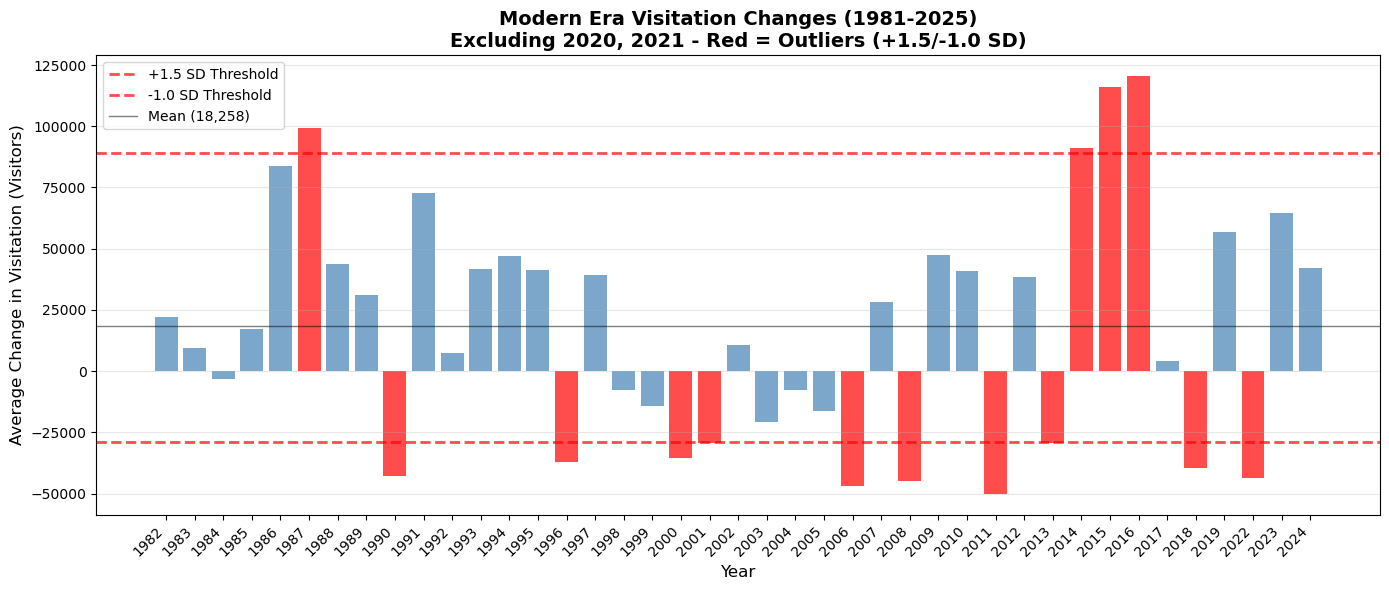


--- Modern Era Summary ---
Years analyzed: 41
Outlier years: 14

Positive outliers (increases > +1.5 SD):
  2016: Z=2.17, Change=120,436
  2015: Z=2.07, Change=115,934
  1987: Z=1.72, Change=99,152

Negative outliers (decreases < -1.0 SD):
  2011: Z=-1.45, Change=-50,094
  2006: Z=-1.39, Change=-47,070
  2008: Z=-1.34, Change=-44,934

Chart saved as: period_1981_2025_modern_era_excl.png


In [11]:
# ============================================================================
# Process Each Time Period
# ============================================================================

all_results = []

for period in TIME_PERIODS:
    START_YEAR = period['start']
    END_YEAR = period['end']
    PERIOD_NAME = period['name']
    
    print("\n" + "="*80)
    print(f"ANALYZING: {PERIOD_NAME} ({START_YEAR}-{END_YEAR})")
    print("="*80)
    
    # Filter to this period's years
    period_years = [y for y in df_all.columns if START_YEAR <= y <= END_YEAR]
    
    # Exclude COVID years if toggle is on
    if EXCLUDE_COVID_YEARS:
        period_years = [y for y in period_years if y not in YEARS_TO_EXCLUDE]
    
    df = df_all[period_years]
    
    print(f"Years in period: {len(df.columns)}")
    print(f"Year range: {df.columns.min()} to {df.columns.max()}")
    
    # Calculate year-over-year changes
    yoy_changes = df.diff(axis=1)
    valid_parks_per_year = yoy_changes.notna().sum(axis=0)
    
    print(f"Parks with data (first year): {valid_parks_per_year.iloc[0] if len(valid_parks_per_year) > 0 else 0}")
    print(f"Parks with data (last year): {valid_parks_per_year.iloc[-1] if len(valid_parks_per_year) > 0 else 0}")
    
    # Calculate z-scores per park (still using symmetric threshold for individual parks)
    z_scores = pd.DataFrame(index=yoy_changes.index, columns=yoy_changes.columns)
    for park in yoy_changes.index:
        park_changes = yoy_changes.loc[park].dropna()
        if len(park_changes) > 0:
            mean_change = park_changes.mean()
            std_change = park_changes.std()
            if std_change > 0:
                z_scores.loc[park] = (yoy_changes.loc[park] - mean_change) / std_change
    
    # For park-level, use the more sensitive threshold
    park_threshold = min(POSITIVE_Z_THRESHOLD, NEGATIVE_Z_THRESHOLD)
    outliers_z = z_scores.abs() > park_threshold
    
    # Aggregate analysis using average
    aggregate_changes = yoy_changes.mean(axis=0, skipna=True)
    years_with_sufficient_data = valid_parks_per_year >= MIN_PARKS_REQUIRED
    aggregate_changes_filtered = aggregate_changes[years_with_sufficient_data]
    
    if len(aggregate_changes_filtered) < 3:
        print(f"⚠️  Insufficient data for period {PERIOD_NAME} - skipping")
        continue
    
    agg_mean = aggregate_changes_filtered.mean()
    agg_std = aggregate_changes_filtered.std()
    
    print(f"\nPeriod Statistics:")
    print(f"  Mean change: {agg_mean:,.0f} visitors")
    print(f"  Std deviation: {agg_std:,.0f} visitors")
    
    if agg_std == 0 or pd.isna(agg_std):
        print(f"⚠️  No variation in data for period {PERIOD_NAME} - skipping")
        continue
    
    aggregate_z_scores = (aggregate_changes_filtered - agg_mean) / agg_std
    
    # ASYMMETRIC OUTLIER DETECTION
    outlier_years = aggregate_z_scores[
        (aggregate_z_scores > POSITIVE_Z_THRESHOLD) |  # Positive outliers
        (aggregate_z_scores < -NEGATIVE_Z_THRESHOLD)    # Negative outliers
    ]
    
    print(f"\nOutlier Years in {PERIOD_NAME}: {list(outlier_years.index)}")
    
    # Visualization
    plt.figure(figsize=(14, 6))
    
    # ASYMMETRIC COLORING
    colors = []
    for z in aggregate_z_scores:
        if z > POSITIVE_Z_THRESHOLD or z < -NEGATIVE_Z_THRESHOLD:
            colors.append('red')
        else:
            colors.append('steelblue')
    
    plt.bar(aggregate_changes_filtered.index.astype(str),
            aggregate_changes_filtered.values, color=colors, alpha=0.7)
    
    # ASYMMETRIC THRESHOLD LINES
    plt.axhline(y=agg_mean + POSITIVE_Z_THRESHOLD * agg_std, color='red', linestyle='--', 
                linewidth=2, alpha=0.7, label=f'+{POSITIVE_Z_THRESHOLD} SD Threshold')
    plt.axhline(y=agg_mean - NEGATIVE_Z_THRESHOLD * agg_std, color='red', linestyle='--', 
                linewidth=2, alpha=0.7, label=f'-{NEGATIVE_Z_THRESHOLD} SD Threshold')
    plt.axhline(y=agg_mean, color='black', linestyle='-', linewidth=1, alpha=0.5,
                label=f'Mean ({agg_mean:,.0f})')
    
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Average Change in Visitation (Visitors)', fontsize=12)
    
    # Title
    if EXCLUDE_COVID_YEARS and any(y in YEARS_TO_EXCLUDE for y in range(START_YEAR, END_YEAR + 1)):
        title = f'{PERIOD_NAME} Visitation Changes ({START_YEAR}-{END_YEAR})\nExcluding {", ".join(map(str, YEARS_TO_EXCLUDE))} - Red = Outliers (+{POSITIVE_Z_THRESHOLD}/-{NEGATIVE_Z_THRESHOLD} SD)'
    else:
        title = f'{PERIOD_NAME} Visitation Changes ({START_YEAR}-{END_YEAR})\nRed = Outliers (+{POSITIVE_Z_THRESHOLD}/-{NEGATIVE_Z_THRESHOLD} SD)'
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='upper left', fontsize=10)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    
    # Save figure
    period_suffix = PERIOD_NAME.lower().replace(' ', '_')
    if EXCLUDE_COVID_YEARS:
        filename = f'period_{START_YEAR}_{END_YEAR}_{period_suffix}_excl.png'
    else:
        filename = f'period_{START_YEAR}_{END_YEAR}_{period_suffix}.png'
    
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    # Store results with asymmetric classification
    is_outlier = (aggregate_z_scores > POSITIVE_Z_THRESHOLD) | (aggregate_z_scores < -NEGATIVE_Z_THRESHOLD)
    
    results_df = pd.DataFrame({
        'Period': PERIOD_NAME,
        'Year': aggregate_changes_filtered.index,
        'Average_Change': aggregate_changes_filtered.values,
        'Z_Score': aggregate_z_scores.values,
        'Is_Outlier': is_outlier,
        'Outlier_Type': is_outlier.map(lambda x: 'None' if not x else 
                                        ('Positive' if aggregate_z_scores[aggregate_z_scores.index[is_outlier.tolist().index(x)]] > 0 
                                         else 'Negative')),
        'Parks_With_Data': valid_parks_per_year[years_with_sufficient_data].values,
        'Period_Mean': agg_mean,
        'Period_StdDev': agg_std
    })
    
    # Fix the Outlier_Type column properly
    outlier_types = []
    for idx, row in results_df.iterrows():
        if row['Is_Outlier']:
            if row['Z_Score'] > 0:
                outlier_types.append('Positive')
            else:
                outlier_types.append('Negative')
        else:
            outlier_types.append('None')
    results_df['Outlier_Type'] = outlier_types
    
    all_results.append(results_df)
    
    # Summary for this period
    print(f"\n--- {PERIOD_NAME} Summary ---")
    print(f"Years analyzed: {len(aggregate_changes_filtered)}")
    print(f"Outlier years: {len(outlier_years)}")
    
    # Separate positive and negative outliers
    positive_outliers = outlier_years[outlier_years > POSITIVE_Z_THRESHOLD]
    negative_outliers = outlier_years[outlier_years < -NEGATIVE_Z_THRESHOLD]
    
    if len(positive_outliers) > 0:
        print(f"\nPositive outliers (increases > +{POSITIVE_Z_THRESHOLD} SD):")
        for year in positive_outliers.sort_values(ascending=False).head(3).index:
            z_val = aggregate_z_scores[year]
            change_val = aggregate_changes_filtered[year]
            print(f"  {year}: Z={z_val:.2f}, Change={change_val:,.0f}")
    
    if len(negative_outliers) > 0:
        print(f"\nNegative outliers (decreases < -{NEGATIVE_Z_THRESHOLD} SD):")
        for year in negative_outliers.sort_values(ascending=True).head(3).index:
            z_val = aggregate_z_scores[year]
            change_val = aggregate_changes_filtered[year]
            print(f"  {year}: Z={z_val:.2f}, Change={change_val:,.0f}")
    
    print(f"\nChart saved as: {filename}")



In [12]:
# ============================================================================
# Combined Results Export
# ============================================================================

if all_results:
    combined_results = pd.concat(all_results, ignore_index=True)
    
    if EXCLUDE_COVID_YEARS:
        csv_filename = 'multi_period_analysis_asymmetric_excl.csv'
    else:
        csv_filename = 'multi_period_analysis_asymmetric.csv'
    
    combined_results.to_csv(csv_filename, index=False)
    print(f"\n{'='*80}")
    print("ANALYSIS COMPLETE")
    print(f"Combined results saved as: {csv_filename}")
    print(f"Total outliers identified: {combined_results['Is_Outlier'].sum()}")
    print(f"  Positive outliers: {(combined_results['Outlier_Type'] == 'Positive').sum()}")
    print(f"  Negative outliers: {(combined_results['Outlier_Type'] == 'Negative').sum()}")
    print("="*80)
else:
    print("\n No periods had sufficient data for analysis")


ANALYSIS COMPLETE
Combined results saved as: multi_period_analysis_asymmetric_excl.csv
Total outliers identified: 25
  Positive outliers: 7
  Negative outliers: 18
